# Analysing the NSS samples

Honestly I don't know the standard way to assess Nested Sampling convergence - here's a pretty picture instead?  
ESS and trace plots don't really make sense in this context because they're sequential with only one particle.  


NB to get unweighted samples from the deadpoints, we have to resample them according to weight  

In [1]:
import numpy as np
import pandas as pd

# ChatGPT's resampling function for nested sampling dead points, returning unweighted samples.

def resample_nested(df, n_live_points, n_samples=None, use_logL=True):
    """
    Numerically stable unweighted resampling of nested‐sampling dead points.

    Parameters
    ----------
    df : pd.DataFrame
        Must contain one row per dead point, in the order they were discarded.
        Must have either 'likelihood' or 'log_likelihood' column.
    n_live_points : int
        Number of live points in the nested sampler.
    n_samples : int, optional
        How many draws you want in the output. Defaults to len(df).
    use_logL : bool
        If True, read df['log_likelihood']; otherwise df['likelihood'].

    Returns
    -------
    pd.DataFrame
        A new DataFrame of shape (n_samples, n_params), drawn (with replacement)
        from the rows of df, unweighted.
    """

    df = df.reset_index(drop=True)
    N = len(df)
    if n_samples is None:
        n_samples = N

    # 1) compute shrinkages X_i
    i = np.arange(1, N+1)
    logX_i   = -i / n_live_points
    logX_im1 = -(i-1) / n_live_points
    X_i   = np.exp(logX_i)
    X_im1 = np.exp(logX_im1)

    # 2) weights w_i = X_{i-1} – X_i
    w = X_im1 - X_i

    # 3) pull in log‐likelihoods (never call exp on them directly)
    if use_logL:
        logL = df['log_likelihood'].values
    else:
        # if you only have 'likelihood' you can log it safely here
        logL = np.log(df['likelihood'].values)

    # 4) log‐posterior weights: log(w_i * L_i) = log w_i + log L_i
    logw = np.log(w)
    logp = logw + logL

    # 5) normalize with log‐sum‐exp trick
    #    subtract the max to avoid overflow
    logp_shifted = logp - np.max(logp)
    p_unnorm     = np.exp(logp_shifted)
    p = p_unnorm / p_unnorm.sum()

    # sanity check
    if np.any(np.isnan(p)):
        raise ValueError("Resampling probabilities contain NaN. "
                         "Check that 'log_likelihood' is finite.")

    # 6) draw indices
    idx = np.random.choice(N, size=n_samples, replace=True, p=p)

    # 7) return resampled DataFrame
    return df.iloc[idx].reset_index(drop=True)


# Don't forget to change the filename
Also you'll need to change n_samples to match the number of dead points accumulated  

..and n_live_points to match whatever value was used.

In [10]:
import pandas as pd
import anesthetic as an


import pandas as pd
import matplotlib.pyplot as plt

# 1) Load your CSV
df = pd.read_csv("NSS_samples_100_live_x1_inner_steps.csv")


df = df.drop(columns=['iteration']) # If you want to eg visualise the samples moving in, then keep iteration column


resampled_unweighted = resample_nested(df, n_live_points=100, n_samples=6700, use_logL=True)


# 2) Extract the samples array and the parameter names
positions = np.array(resampled_unweighted)          # shape (n_samples, n_parameters)   #Nota bene: we would usually throw away the burn in period but I have chosen to make it visible here
names = list(resampled_unweighted)        # ['theta1', 'theta2', ...]   

print(positions.shape)
print(names)


(6700, 8)
['log_likelihood', 'sfh_0', 'sfh_1', 'sfh_2', 'sigma', 'zh_0', 'zh_1', 'zh_2']


In [ ]:




# 3) Wrap into an anesthetic MCMCSamples object
true_sfh = np.array([ 0.1 ,  5.05, 10.  ] + [4.490435e-05, 4.490435e-05, 4.490435e-05])
true_zh = np.array([4.490435e-05, 4.490435e-05, 4.490435e-05])

from anesthetic.samples import Samples
samples = Samples(resampled_unweighted)
samples.plot_2d(figsize=(12,12), truth=true_sfh, truth_label='True SFH', truth_color='red', truth_alpha=0.5)

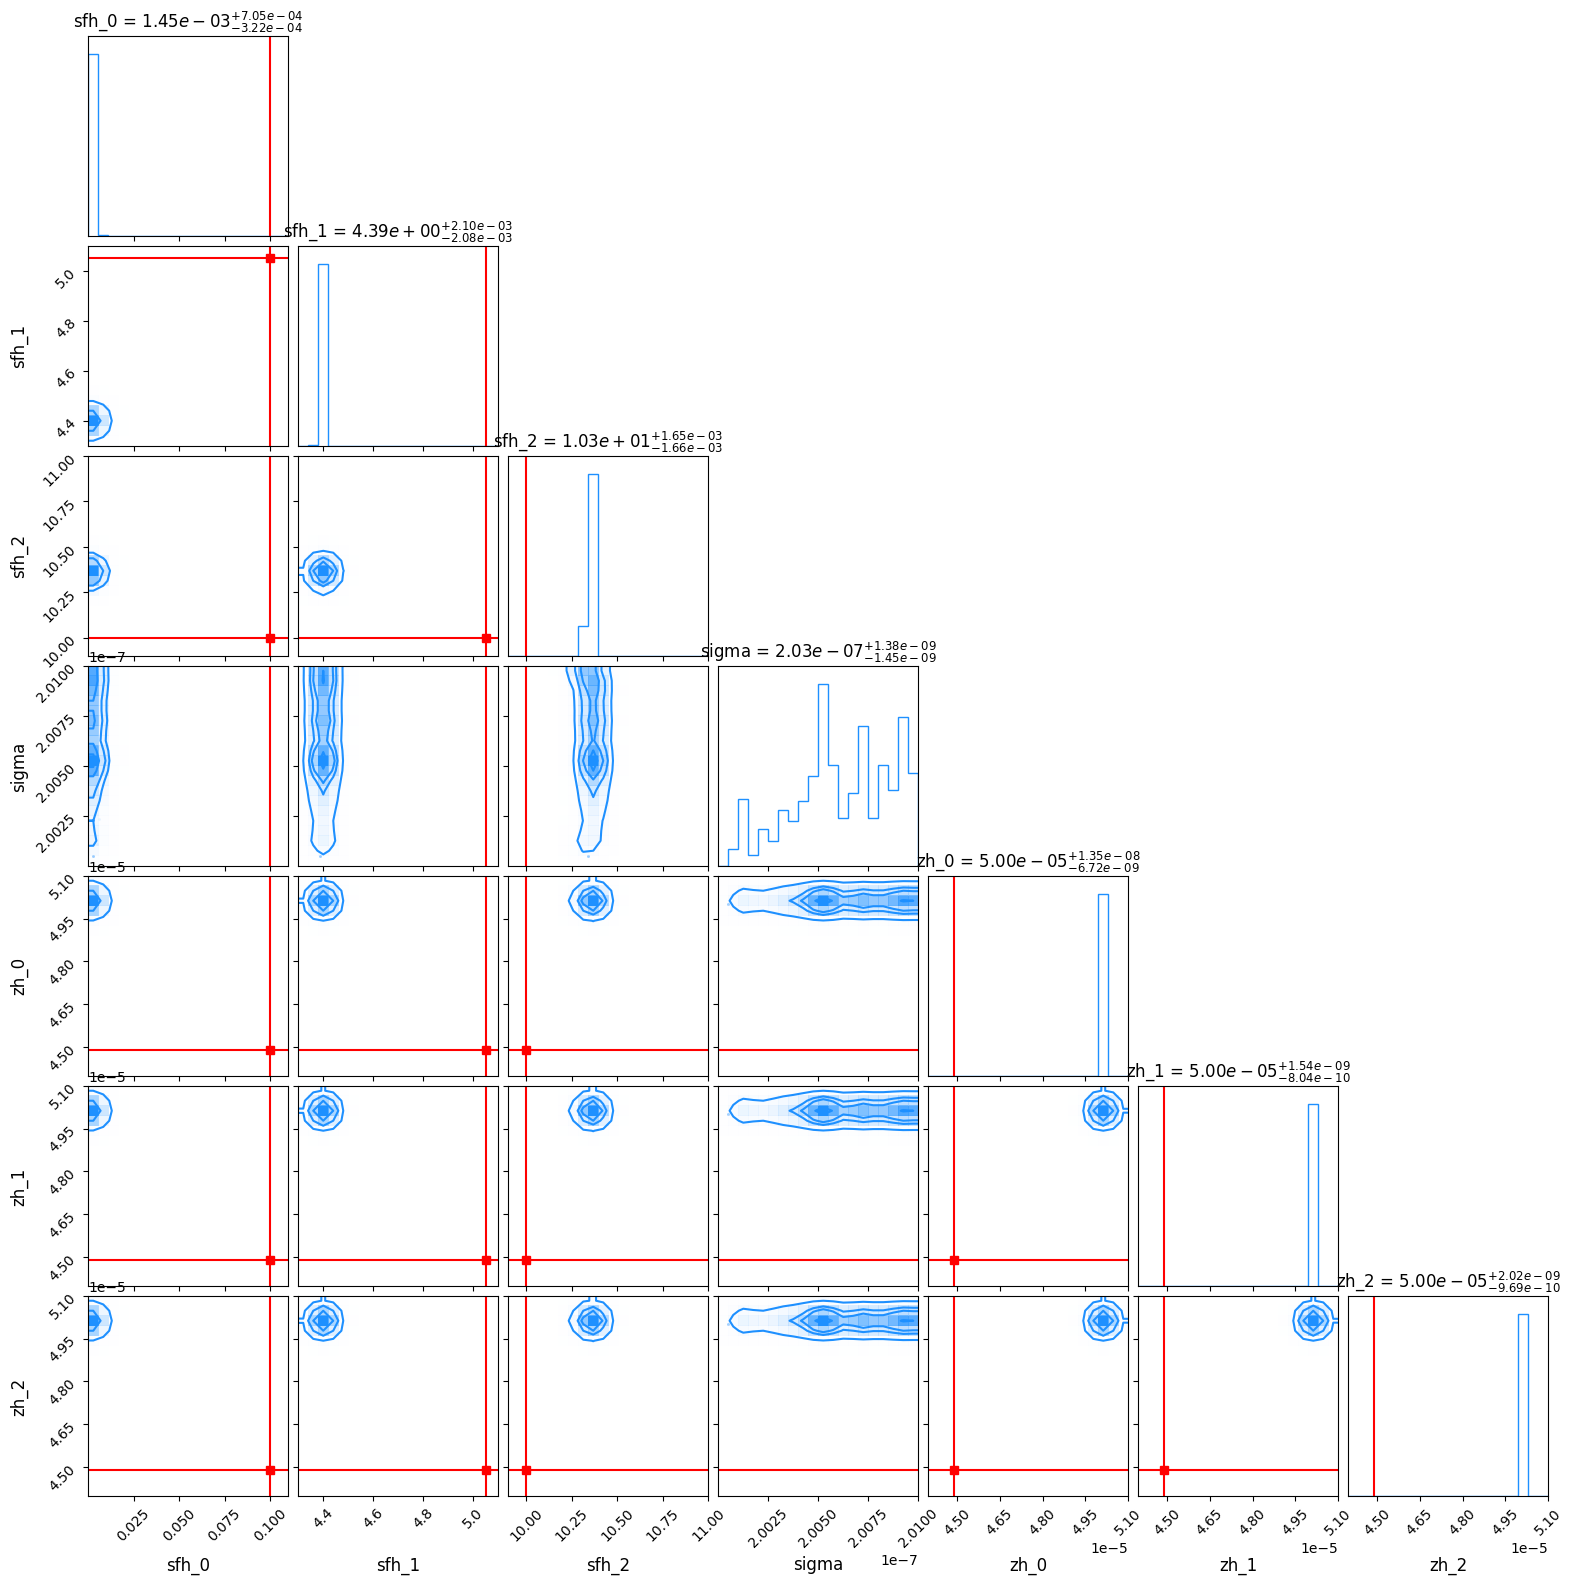

In [39]:
import corner
import numpy as np
import matplotlib.pyplot as plt

# Your inputs
paramnames = ['log_likelihood', 'sfh_0', 'sfh_1', 'sfh_2', 'sigma', 'zh_0', 'zh_1', 'zh_2']
truth = np.array([0.1, 5.05, 10., 1e-7, 4.490435e-05, 4.490435e-05, 4.490435e-05])
positions_subset = positions[:, 1:]         # shape (6700, 7)
labels_subset = paramnames[1:]              # drop 'log_likelihood'
ranges = [(1e-4, 0.11), (4.3, 5.1), (9.9, 11), (2e-7, 2.01e-7), (4.4e-5, 5.1e-5), (4.4e-5, 5.1e-5), (4.4e-5, 5.1e-5)]
# Make the plot
fig = corner.corner(
    positions_subset,
    labels=labels_subset,
    range=ranges,
    color='dodgerblue',
    smooth=True,
    truths=truth,
    show_titles=True,
    title_fmt=".2e",
    label_kwargs={"fontsize": 12},
    truth_color='red'
)
plt.savefig("corner_plot.pdf", dpi=300, bbox_inches='tight')
plt.show()

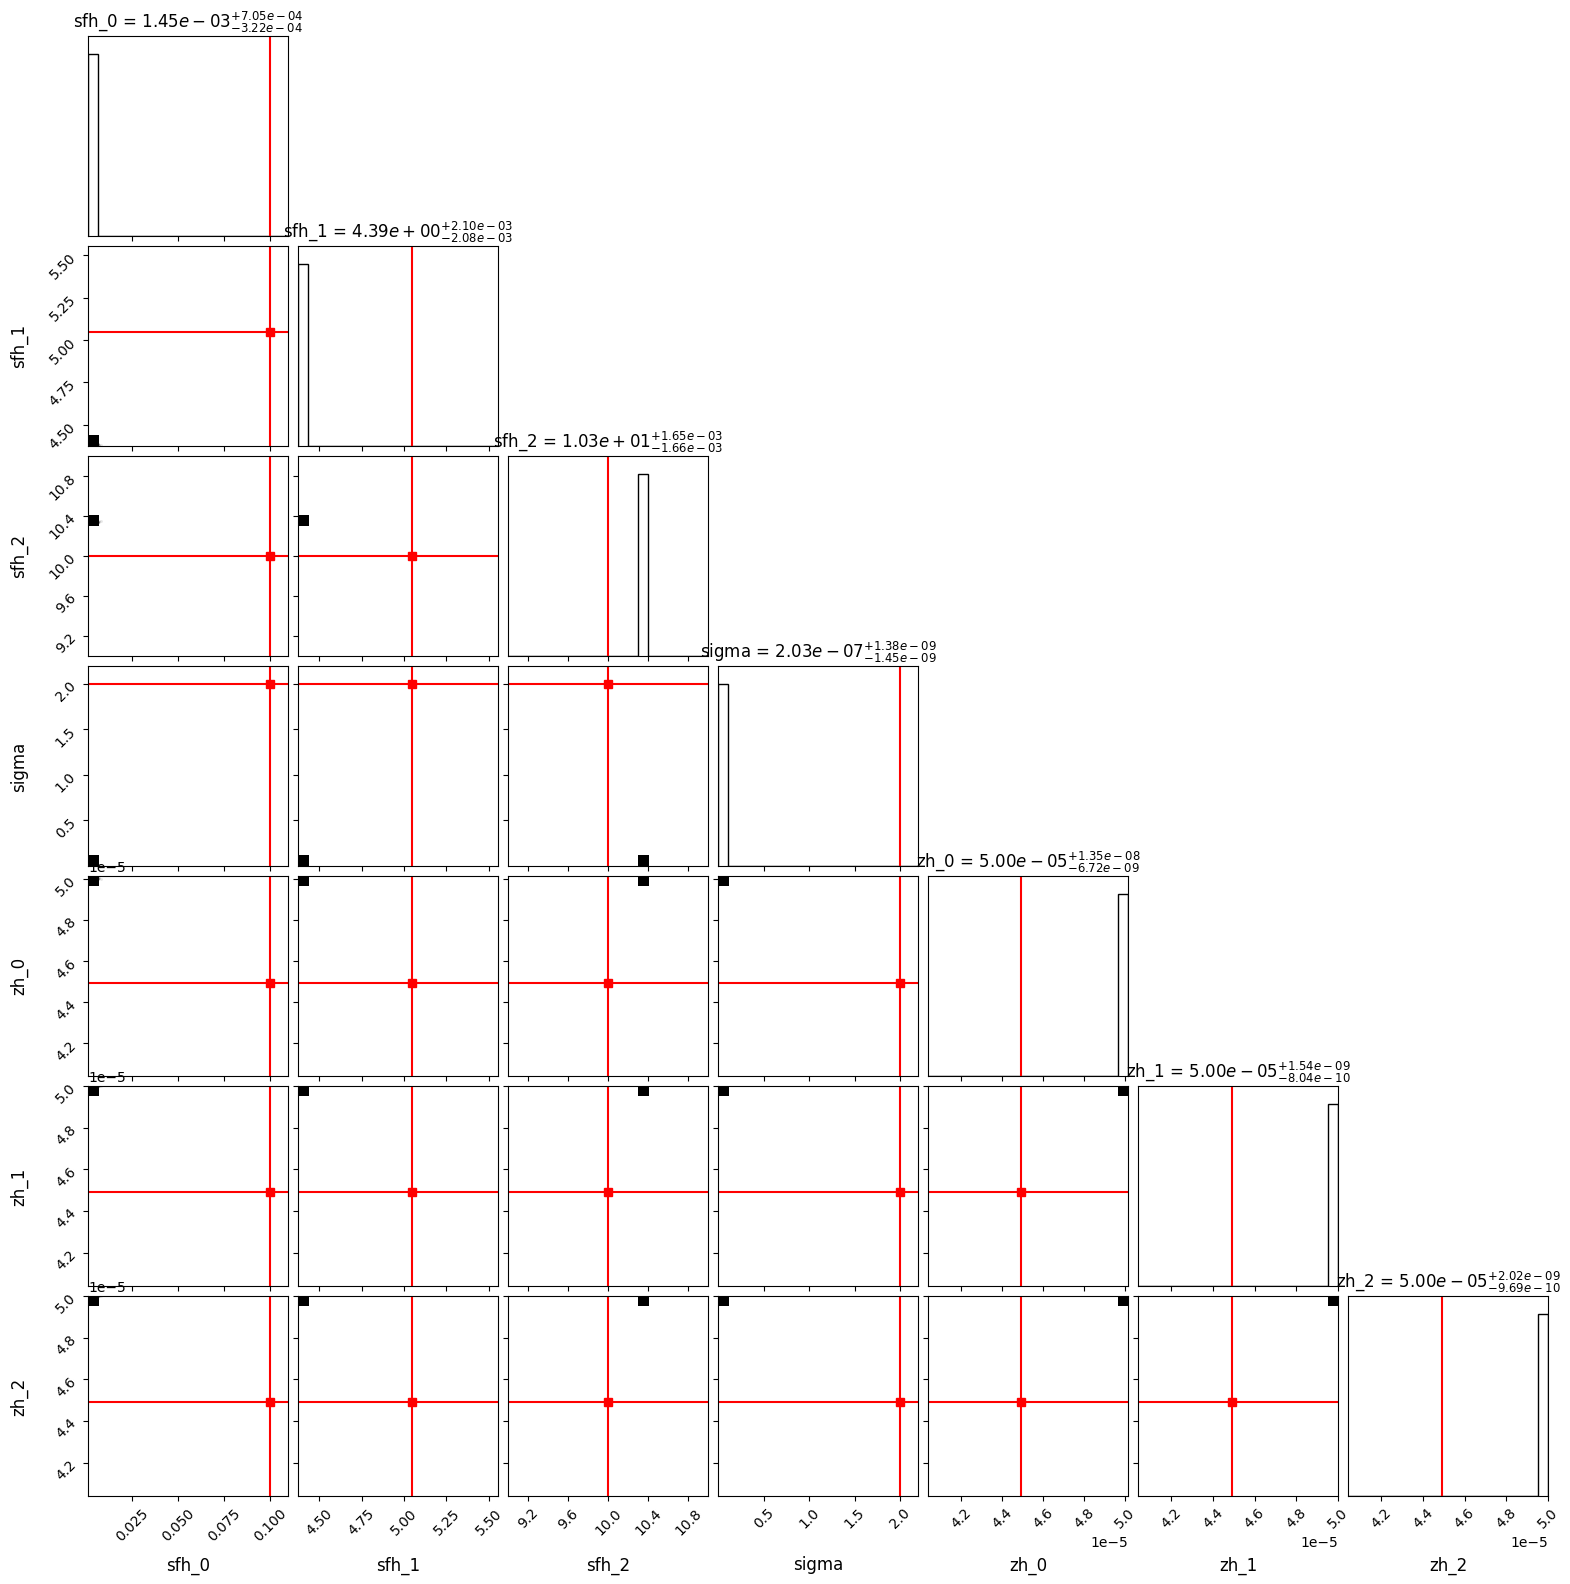

In [16]:
import numpy as np
import matplotlib.pyplot as plt
import corner

# Inputs
paramnames = ['log_likelihood', 'sfh_0', 'sfh_1', 'sfh_2', 'sigma', 'zh_0', 'zh_1', 'zh_2']
truth = np.array([0.1, 5.05, 10., 2, 4.490435e-05, 4.490435e-05, 4.490435e-05])

# Drop log_likelihood
positions_subset = positions[:, 1:]         # shape (N, 7)
labels_subset = paramnames[1:]              # matching 7 labels

# Compute per-dimension ranges that include truth values
lower_bounds = np.minimum(np.min(positions_subset, axis=0), truth * 0.9)
upper_bounds = np.maximum(np.max(positions_subset, axis=0), truth * 1.1)
ranges = list(zip(lower_bounds, upper_bounds))

# Plot
fig = corner.corner(
    positions_subset,
    labels=labels_subset,
    truths=truth,
    show_titles=True,
    title_fmt=".2e",
    label_kwargs={"fontsize": 12},
    truth_color='red',
    range=ranges,
)

plt.show()

In [30]:
quantiles = np.percentile(positions_subset, [50], axis=0)

In [31]:
quantiles

array([[1.45303055e-03, 4.38586214e+00, 1.03418177e+01, 2.02880845e-07,
        5.00093335e-05, 5.00010768e-05, 5.00013603e-05]])